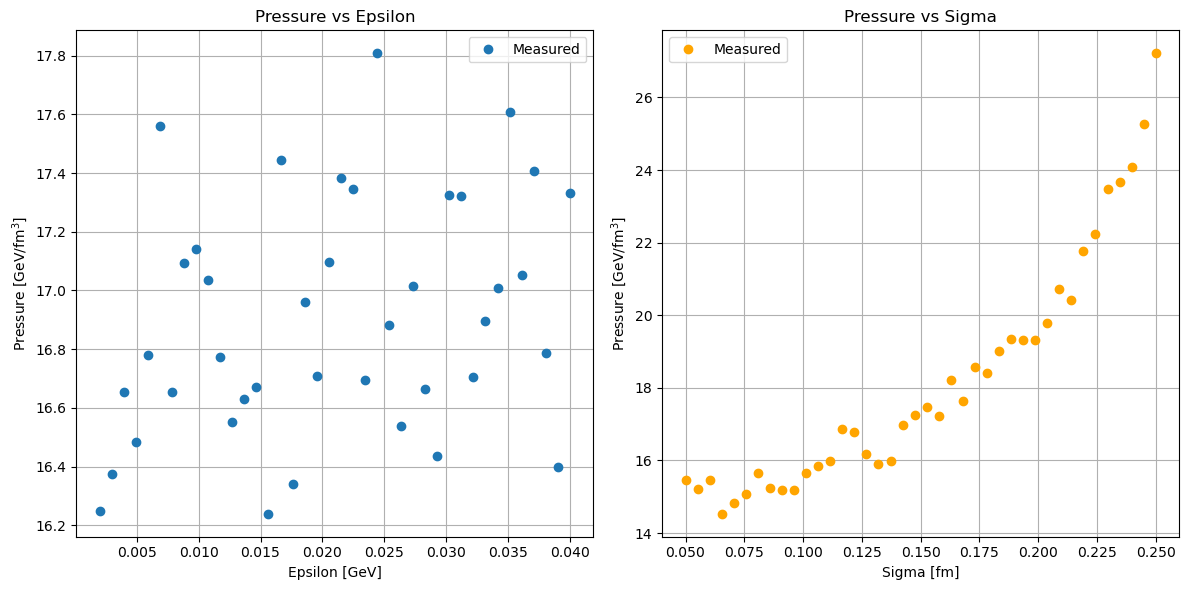

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you loaded the data like this:
scan_eps_data = pd.read_csv('scan_epsilon.csv')
scan_sig_data = pd.read_csv('scan_sigma.csv')

plt.figure(figsize=(12, 6))

# Plot 1: Pressure vs Epsilon
plt.subplot(1, 2, 1)
# Plotting Epsilon on the x-axis and P_measured on the y-axis
plt.plot(scan_eps_data["Epsilon"], scan_eps_data["P_measured"], marker='o', linestyle='none', label='Measured')
# Optionally, you can also add the theoretical values
# plt.plot(scan_eps_data["Epsilon"], scan_eps_data["P_theory"], 'r--', label='Theory')
plt.title("Pressure vs Epsilon")
plt.xlabel("Epsilon [GeV]")
plt.ylabel("Pressure [GeV/fm$^3$]")
plt.legend()
plt.grid()

# Plot 2: Pressure vs Sigma
plt.subplot(1, 2, 2)
# Plotting Sigma on the x-axis and P_measured on the y-axis
plt.plot(scan_sig_data["Sigma"], scan_sig_data["P_measured"], marker='o', color='orange', linestyle='none', label='Measured')
# Optionally, you can also add the theoretical values
# plt.plot(scan_sig_data["Sigma"], scan_sig_data["P_theory"], 'r--', label='Theory')
plt.title("Pressure vs Sigma")
plt.xlabel("Sigma [fm]")
plt.ylabel("Pressure [GeV/fm$^3$]")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


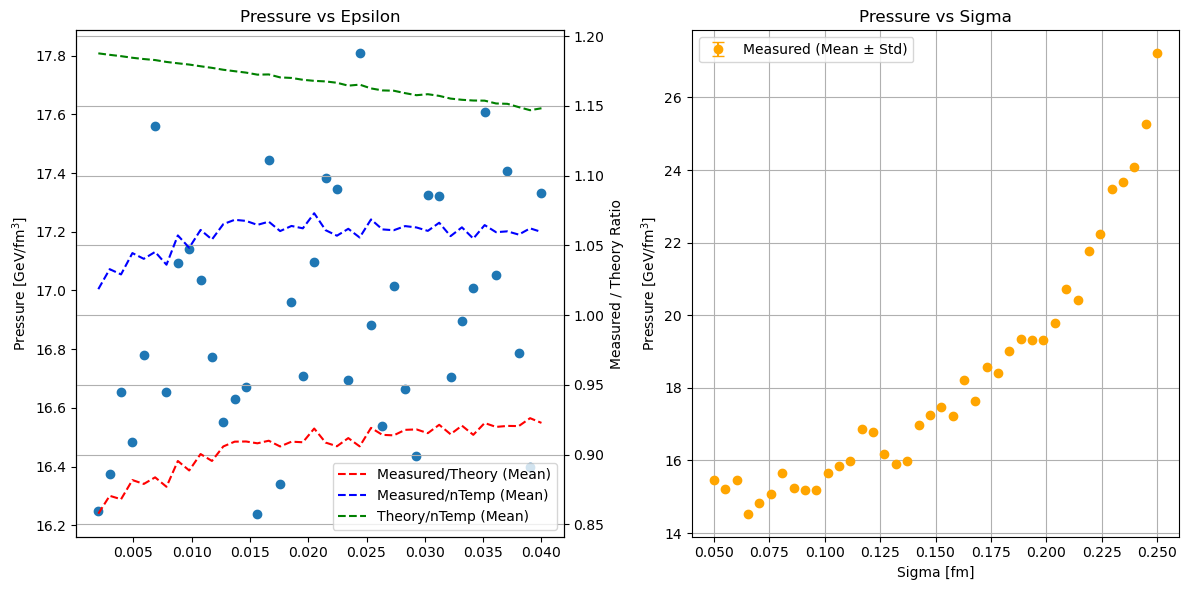

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
scan_eps_data = pd.read_csv('scan_epsilon.csv')
scan_sig_data = pd.read_csv('scan_sigma.csv')

# Group by the scanned parameter and calculate the mean and standard deviation (std)
# We also take the mean of the theory column just to collapse the duplicate values
eps_stats = scan_eps_data.groupby("Epsilon").agg(
    P_measured_mean=('P_measured', 'mean'),
    P_measured_std=('P_measured', 'std'),
    P_theory_mean=('P_theory', 'mean'),
    Temp=('Temp', 'mean')
).reset_index()

sig_stats = scan_sig_data.groupby("Sigma").agg(
    P_measured_mean=('P_measured', 'mean'),
    P_measured_std=('P_measured', 'std'),
    P_theory_mean=('P_theory', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))

# Plot 1: Pressure vs Epsilon
plt.subplot(1, 2, 1)
# Plotting with error bars
plt.errorbar(
    eps_stats["Epsilon"], 
    eps_stats["P_measured_mean"], 
    yerr=eps_stats["P_measured_std"], 
    fmt='o',             # 'o' gives us the scatter points without connecting lines
    capsize=4,           # Adds caps to the ends of the error bars
    label='Measured (Mean ± Std)'
)
# plt.plot(eps_stats["Epsilon"], eps_stats["P_measured_mean"]/eps_stats["P_theory_mean"], 'r--', label='Measured/Theory (Mean)', yaxis='right')
plt.ylabel("Pressure [GeV/fm$^3$]")
# plt.legend()
ax2 = plt.twinx()

N = 32
# Plot your ratio on the new secondary axis
ax2.plot(
    eps_stats["Epsilon"], 
    eps_stats["P_measured_mean"] / eps_stats["P_theory_mean"], 
    'r--', 
    label='Measured/Theory (Mean)'
)
ax2.plot(
    eps_stats["Epsilon"], 
    eps_stats["P_measured_mean"] / eps_stats["Temp"] / N, 
    'b--', 
    label='Measured/nTemp (Mean)'
)
ax2.plot(
    eps_stats["Epsilon"], 
    eps_stats["P_theory_mean"] / eps_stats["Temp"] / N, 
    'g--', 
    label='Theory/nTemp (Mean)'
)
ax2.set_ylabel("Measured / Theory Ratio") # Label for the right y-axis

plt.title("Pressure vs Epsilon")
plt.xlabel("Epsilon [GeV]")
# plt.ylabel("Pressure [GeV/fm$^3$]")
plt.legend()
plt.grid()

# Plot 2: Pressure vs Sigma
plt.subplot(1, 2, 2)
# Plotting with error bars
plt.errorbar(
    sig_stats["Sigma"], 
    sig_stats["P_measured_mean"], 
    yerr=sig_stats["P_measured_std"], 
    fmt='o', 
    color='orange',
    ecolor='orange',     # Ensures the error bars match the marker color
    capsize=4, 
    label='Measured (Mean ± Std)'
)
# plt.plot(sig_stats["Sigma"], sig_stats["P_theory_mean"], 'r--', label='Theory')
plt.title("Pressure vs Sigma")
plt.xlabel("Sigma [fm]")
plt.ylabel("Pressure [GeV/fm$^3$]")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()
